In [1]:
from ibl_schema.schema import *
from one.api import ONE 
from damn import *

%load_ext autoreload
%autoreload 2

one = ONE()
# get some data, a good visually responsive cell
eid = 'fa980b8d-a023-4b39-af9d-1d78c5e0c600'
eids, details = one.search(id=eid, details=True)
eid = eids[0]
metadata = details[0]
wheel = one.load_object(eid, 'wheel')
trials = one.load_object(eid, 'trials')

print(metadata)

c:\Users\mmelin\anaconda3\envs\spks\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-05 14:19:25,394][INFO]: DataJoint 0.14.6 connected to mmelin@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


In [ ]:
session = dict(subject_name=metadata['subject'],
               session_datetime=metadata['date'])
sorting = dict(parameter_set_num=5, # KS4.0
               unit_criteria_id=1, # apply single unit metrics
               passes=1,)
histology = dict()
#unit = dict(unit_id=69,
#            probe_num=0)
#unit = dict(unit_id=248,
#            probe_num=5)
units = [dict(unit_id=661, # stim neuron
            probe_num=4),
         dict(unit_id=574, # correct neuron
            probe_num=1),
         dict(unit_id=281,  # stim?
            probe_num=5),
         dict(unit_id=248,  # stim?
            probe_num=5),
         dict(unit_id=700,  # choice?
            probe_num=0),]
#units = [units[0]]
query = Session() * SpikeSorting.Unit() * UnitCount.Unit & session & sorting & units
dat = (SpikeSorting().Unit() & query.proj()).get_spike_times()
spike_times = [d['spike_times'] for d in dat]
len(spike_times), len(trials.stimOn_times)
#query.fetch('KEY',as_dict=True)[9]

In [1]:
# verify the cell responds to right contrasts

from damn.alignment import compute_spike_count
from spks.viz import plot_event_aligned_raster
from spks.utils import gaussian_function

#BWMS = 1
BWMS = 3
#BWMS = 25
#BWMS = 100
master_alignment_times = trials.stimOn_times
pres = .5
posts = 1.4
bwidth = BWMS / 1000

contrast = np.where(np.isnan(trials.contrastRight), -trials.contrastLeft, trials.contrastRight)


all = []
for s in spike_times:
    peth, timebin_centers, event_ind = compute_spike_count(master_alignment_times, s, pre_seconds=pres, post_seconds=posts, binwidth_s=BWMS/1000)
    all.append(peth)
peth = np.stack(all)
n_units, n_trials, samples_per_trial = peth.shape

NameError: name 'trials' is not defined

In [ ]:
from ibl_schema.wheel import aligned_wheel_traces
last_spike_time = np.max([s[-1] for s in spike_times])
whl, whl_vel, whl_t, _ = aligned_wheel_traces(wheel.timestamps, wheel.position, [0], 0, last_spike_time, return_velocity=True, fs=1000)
whl_vel = whl_vel.T
abs_whl_vel = np.abs(whl_vel)

In [ ]:
Y = np.reshape(peth, (n_units, n_trials*samples_per_trial,), order='C').T

In [ ]:
import cProfile
import pstats

profiler = cProfile.Profile()
profiler.enable()

wheel_vel_right = np.where(whl_vel>0, whl_vel, 0)
wheel_vel_left = np.where(whl_vel<0, -whl_vel, 0)

wheel_right = ContinuousRegressor('wheel_right_vel', whl_t, wheel_vel_right, bwidth, tags='wheel')
wheel_right.add_basis_function('raised_cosine', .5, 0, n_funcs=5, log_scale=True)
wheel_right.add_basis_function('raised_cosine', 0, .3, n_funcs=5, log_scale=True)
wheel_left = ContinuousRegressor('wheel_left_vel', whl_t, wheel_vel_left, bwidth, tags='wheel')
wheel_left.add_basis_function('raised_cosine', .5, 0, n_funcs=5, log_scale=True)
wheel_left.add_basis_function('raised_cosine', 0, .3, n_funcs=5, log_scale=True)

dmat = DesignMatrix(master_alignment_times,
                    pres, posts, bwidth)

dmat.add_regressor(wheel_right)
dmat.add_regressor(wheel_left)


dmat.build_matrix()

profiler.disable()

In [ ]:
pstats.Stats(profiler).sort_stats("cumulative").print_stats()

In [1]:
from ibl_schema.schema import *
from one.api import ONE 
from damn import *
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

one = ONE()
# get some data, a good visually responsive cell
eid = 'fa980b8d-a023-4b39-af9d-1d78c5e0c600'
eids, details = one.search(id=eid, details=True)
eid = eids[0]
metadata = details[0]
wheel = one.load_object(eid, 'wheel')
trials = one.load_object(eid, 'trials')

print(metadata)

c:\Users\mmelin\anaconda3\envs\spks\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-06 20:07:26,934][INFO]: DataJoint 0.14.6 connected to mmelin@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


{'id': 'fa980b8d-a023-4b39-af9d-1d78c5e0c600', 'subject': 'MM030', 'start_time': '2025-10-30T14:04:48.777989', 'number': 1, 'lab': 'churchlandlab_ucla', 'projects': ['U19_chronic_NP'], 'url': 'https://alyx.internationalbrainlab.org/sessions/fa980b8d-a023-4b39-af9d-1d78c5e0c600', 'task_protocol': '_iblrig_tasks_trainingChoiceWorld8.29.0/_iblrig_tasks_passiveChoiceWorld8.29.0', 'date': datetime.date(2025, 10, 30)}


In [2]:
stimtimes = trials.stimOn_times
# randomly chooose 1 to 8 for position
stimpos = np.random.randint(1,100,size=stimtimes.shape)

stim = np.vstack([stimtimes,stimpos]).T

bw = 3/1000
#bw = 100/1000


In [3]:
def _compute_bin_edges_and_indices(vals, spec):
    """
    Compute bin edges and indices for a single dimension.
    
    Parameters
    ----------
    vals : ndarray, shape (n_events,)
        Values along this dimension.
    spec : float, int, array-like, or None
        - float/int: binwidth → auto bins
        - array-like: pre-defined edges
        - None: fully one-hot encode unique values
    
    Returns
    -------
    edges : ndarray
        Bin edges (or unique values if one-hot)
    indices : ndarray
        Bin index for each value
    n_bins : int
        Number of bins
    """
    vals = np.asarray(vals)
    
    if spec is None:
        # Fully one-hot encode unique values
        edges = np.unique(vals)
        indices = np.searchsorted(edges, vals, side='left')
        n_bins = len(edges)
    elif isinstance(spec, (float, int)):
        bw = float(spec)
        edges = np.arange(vals.min(), vals.max() + bw, bw)
        indices = np.searchsorted(edges, vals, side='right') - 1
        indices = np.clip(indices, 0, len(edges) - 2)
        n_bins = len(edges) - 1
    else:
        edges = np.asarray(spec)
        indices = np.searchsorted(edges, vals, side='right') - 1
        indices = np.clip(indices, 0, len(edges) - 2)
        n_bins = len(edges) - 1

    return edges, indices, n_bins

def nd_one_hot(events, bin_specs=None):
    """
    One-hot encode events along N dimensions.

    Parameters
    ----------
    events : ndarray, shape (n_events, n_dims)
        Event coordinates along N dimensions.
    bin_specs : list of length n_dims, optional
        For each dimension:
        - float/int: binwidth → auto-create bins based on min/max of events
        - array-like: pre-specified bin edges
        - None: fully 1-hot encode each unique value in this dimension

        If None, defaults to fully one-hot encoding all dimensions.

    Returns
    -------
    mat : ndarray
        N-dimensional array of counts per bin combination.
    bin_edges : list of ndarray
        Bin edges (or unique values if one-hot) for each axis.
    """
    events = np.asarray(events)
    n_events, n_dims = events.shape

    # -------------------------------
    # Step 0: Remove any NaNs
    # -------------------------------
    valid_mask = ~np.isnan(events).any(axis=1)
    events = events[valid_mask]
    n_events = len(events)
    binwidths = []

    if bin_specs is None:
        bin_specs = [None] * n_dims

    if len(bin_specs) != n_dims:
        raise ValueError("bin_specs must have length equal to number of dimensions")

    bin_edges = []
    n_bins_list = []
    indices_list = []

    # Compute bin edges and indices for each dimension
    for i in range(n_dims):
        edges, indices, n_bins = _compute_bin_edges_and_indices(events[:, i], bin_specs[i])
        bin_edges.append(edges)
        indices_list.append(indices)
        n_bins_list.append(n_bins)
    
    # convert edges to binwidth
    binwidths = [np.diff(edges).mean() for edges in bin_edges]

    # Stack indices and linearize
    idxs = np.stack(indices_list, axis=1)
    strides = np.cumprod([1] + n_bins_list[:-1])
    flat_indices = np.sum(idxs * strides, axis=1)

    # Accumulate counts
    counts = np.bincount(flat_indices, minlength=np.prod(n_bins_list))
    mat = counts.reshape(n_bins_list)
    
    

    return mat, bin_edges, binwidths

X, b, bws = nd_one_hot(stim, bin_specs=[bw, None])

(666, 5) (25, 3)


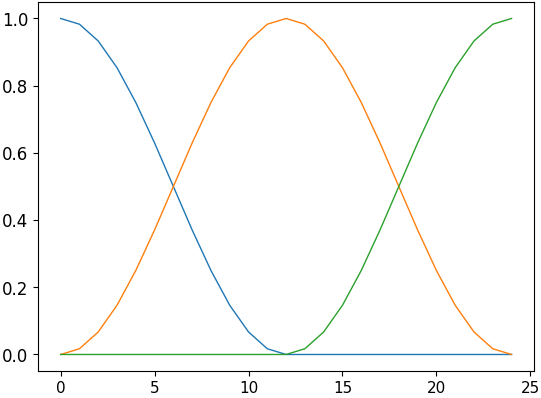

In [4]:
bw1 = np.mean(np.diff(b[0]))
bw2 = np.mean(np.diff(b[1]))
basis = raised_cosine_basis(5, 1, 0, bw)
#basis2 = raised_cosine_basis(3, 13, 13, 1)
basis2 = raised_cosine_basis(3, 13, 13, 1)
#basis2 = raised_cosine_basis(3, 13, 0, 1)
print(basis.shape, basis2.shape)
#basis2 = raised_cosine_basis(3, 0, 3, bw2)
plt.plot(basis2)

In [5]:
import cupy as cp
from cupyx.scipy.signal import fftconvolve
from cupyx.scipy.ndimage import convolve1d
import torch
import torch.nn.functional as F


def convolve_along_axes_torch_nd(X, bases, device="cuda"):
    # TODO: add option for the following
    # perform full multidimenional convolution all at once
    # perform convolution just along corresponding axis
    # perform convolution along corresponding axis, then take that result and convole along the next axis, etc.
    # I think the first option is best, so need to put the kernels together into a single kernel that can be convolved with the entire X at once. This is a bit tricky but should be possible by using the fact that convolution is associative and commutative, and by properly reshaping the kernels to match the dimensions of X.
    X_t = torch.as_tensor(X, dtype=torch.float32, device=device)
    conv_results = []
    N = X_t.ndim

    for axis, axis_bases in enumerate(bases):
        bases_t = torch.as_tensor(axis_bases, dtype=torch.float32, device=device)
        kernel_length, n_basis_funcs = bases_t.shape

        axis_convs = []

        for i in range(n_basis_funcs):
            kernel = bases_t[:, i]

            # Move axis → last
            perm = list(range(N))
            perm[axis], perm[-1] = perm[-1], perm[axis]
            Xp = X_t.permute(perm)

            orig_shape = Xp.shape
            L = orig_shape[-1]

            Xf = Xp.reshape(-1, 1, L)

            # SciPy-exact padding
            pad_left = (kernel_length - 1) // 2
            pad_right = (kernel_length - 1) - pad_left
            Xf = F.pad(Xf, (pad_left, pad_right))

            k = kernel.flip(0).view(1, 1, -1)

            Y = F.conv1d(Xf, k, padding=0)

            # reshape back
            Y = Y.view(orig_shape)
            Y = Y.permute(perm)

            axis_convs.append(Y)

        axis_convs = torch.stack(axis_convs, dim=-1)
        conv_results.append(axis_convs.cpu().numpy())

    return conv_results

    

c:\Users\mmelin\anaconda3\envs\spks\lib\site-packages\cupyx\jit\_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [6]:
import itertools

def build_nd_separable_kernel(bases, device=None):
    """
    Build an N-D separable convolution kernel from 1D basis banks.

    Parameters
    ----------
    bases : list of tensors
        bases[k].shape = (Lk, Bk)
    device : torch device or None

    Returns
    -------
    K : tensor
        Shape (prod(Bk), 1, L1, L2, ..., LN)
    """
    bases = [
        torch.as_tensor(b, dtype=torch.float32, device=device).flip(0)
        for b in bases
    ]

    lengths = [b.shape[0] for b in bases]
    n_bases = [b.shape[1] for b in bases]

    # All index combinations (b1, b2, ..., bN)
    combos = list(itertools.product(*[range(n) for n in n_bases]))

    kernels = []

    for combo in combos:
        # Start with scalar 1
        K = 1.0

        for axis, bi in enumerate(combo):
            v = bases[axis][:, bi]

            # reshape to broadcast along correct axis
            shape = [1] * len(bases)
            shape[axis] = -1
            v = v.view(*shape)

            K = K * v

        kernels.append(K)

    # Stack into output channels
    K = torch.stack(kernels, dim=0)

    # Add input channel dim
    K = K.unsqueeze(1)

    return K

def convolve_nd_separable(X, bases, device="cuda"):
    torch.cuda.empty_cache()
    X_t = torch.as_tensor(X, dtype=torch.float32, device=device)

    # Build kernel
    K = build_nd_separable_kernel(bases, device=device)
    print(K.shape)
    print(X.shape)

    # Add batch + channel dims
    X_t = X_t.unsqueeze(0).unsqueeze(0)

    # SAME-style padding
    pads = []
    for b in reversed(bases):
        L = b.shape[0]
        left = (L - 1) // 2
        right = (L - 1) - left
        pads.extend([left, right])

    X_t = F.pad(X_t, pads,)

    # N-D convolution
    #Y = F.conv_nd(X_t, K)
    Y = F.conv2d(X_t, K,)
    return Y.squeeze(0)#.cpu().numpy()

In [7]:
import itertools
import jax
import jax.numpy as jnp
from jax import lax

def build_nd_separable_kernel_jax(bases):
    bases = [jnp.flip(jnp.array(b, dtype=jnp.float32), axis=0) for b in bases]

    n_bases = [b.shape[1] for b in bases]
    combos = list(itertools.product(*[range(n) for n in n_bases]))

    kernels = []
    for combo in combos:
        K = 1.0
        for axis, bi in enumerate(combo):
            v = bases[axis][:, bi]
            shape = [1] * len(bases)
            shape[axis] = -1
            v = v.reshape(shape)
            K = K * v
        kernels.append(K)

    K = jnp.stack(kernels, axis=0)
    K = K[:, None, ...]  # add input channel dim
    return K


def convolve_nd_separable_jax(X, bases):
    """
    Convolve N-D array X with separable basis kernels (JAX version).
    Works for arbitrary N and uses SAME padding.
    """
    X_t = jnp.array(X, dtype=jnp.float32)
    N = X_t.ndim

    # Add batch + channel dims
    X_t = X_t[None, None, ...]  # (1, 1, D1, ..., DN)

    # Build kernel
    K = build_nd_separable_kernel_jax(bases)  # (out_channels, in_channels=1, L1, ..., LN)

    # Window strides
    strides = (1,) * N

    # Convolve using lax.conv_general_dilated with integer dimension_numbers
    # LHS dims: (batch, in_chan, spatial...)
    # RHS dims: (out_chan, in_chan, spatial...)
    # OUT dims: (batch, out_chan, spatial...)
    dimension_numbers = lax.ConvDimensionNumbers(
        lhs_spec=(0, 1) + tuple(range(2, 2+N)),
        rhs_spec=(0, 1) + tuple(range(2, 2+N)),
        out_spec=(0, 1) + tuple(range(2, 2+N))
    )

    Y = lax.conv_general_dilated(
        lhs=X_t,
        rhs=K,
        window_strides=strides,
        padding="SAME",
        dimension_numbers=dimension_numbers
    )

    return jnp.squeeze(Y, axis=0)  # remove batch dim

In [8]:
#Xconv2 = convolve_along_axes_gpu_nd(X, [basis, basis2])
#Xconv2 = convolve_along_axes_torch_nd(X, [basis, basis2])
Xconv3 = convolve_nd_separable(X, [basis, basis2])
#Xconv3 = convolve_nd_separable_jax(X, [basis, basis2])

torch.Size([15, 1, 666, 25])
(1324272, 99)


In [10]:
Xconv3[:,0,0]

(666, 5) (25, 3)
torch.Size([15, 1, 666, 25])


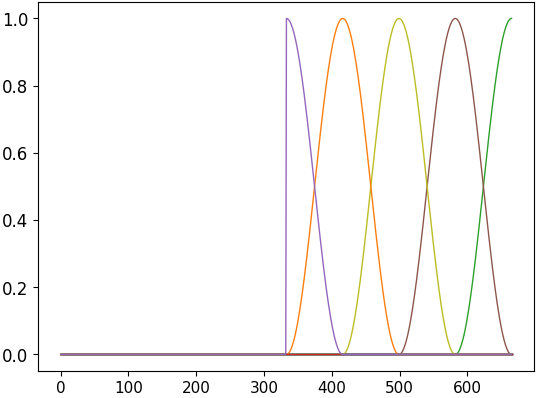

In [8]:
bases = [basis, basis2]
print(basis.shape, basis2.shape)
K = build_nd_separable_kernel(bases)

print(K.shape)  # (3*4, 1, 3, 4)
plt.plot(K[:,0,:,0].T)
#plt.plot(K[:,0,600,:].T)


In [ ]:
def get_rf(K, combo, n_bases):
    """
    Extract the N-dimensional receptive field from a separable kernel.

    Parameters
    ----------
    K : torch.Tensor
        Kernel tensor of shape (prod(n_bases), 1, L1, L2, ..., LN)
    combo : tuple of ints
        Which basis to use along each axis, length N
    n_bases : list of ints
        Number of bases along each axis, length N

    Returns
    -------
    rf : torch.Tensor
        N-dimensional receptive field of shape (L1, L2, ..., LN)
    """
    assert len(combo) == len(n_bases), "combo length must match number of axes"

    # Compute channel index in the flattened kernel
    channel_idx = 0
    for i, b in enumerate(combo):
        stride = 1
        for nb in n_bases[i+1:]:
            stride *= nb
        channel_idx += b * stride

    # Extract RF
    rf = K[channel_idx, 0]  # remove input channel dim
    return rf

In [297]:
#pstats.Stats(profiler).sort_stats("cumulative").print_stats()
# it turns out full convolving may not be the best, the data are spare, 

In [336]:
Xconv2[1].shape

(1324272, 99, 3)

In [10]:
timeinds = np.where(X[:,0] == 1)[0]
timeinds = timeinds[0]
timeinds

np.int64(141306)

In [11]:
#Xconv2[0].shape
Xconv3.shape

torch.Size([15, 1324272, 99])

In [12]:
# check the temporal convolution
#inds = np.arange(71000, 75000)inds
w = 500
plt.plot(X[timeinds-w:timeinds+w, 0] + 2)
#plt.plot(Xconv[0][timeinds-w:timeinds+w,0,:] + 1)
#plt.plot(Xconv2[0][timeinds-w:timeinds+w,0,:])
plt.plot(Xconv3[:,timeinds-w:timeinds+w,0].cpu())

In [318]:
Xconv2[1].shape, X.shape

((1324272, 99, 3), (1324272, 99))

In [319]:
timeinds2 = np.where(X[:,30] > 0)[0]
timeinds2 = timeinds2[0]

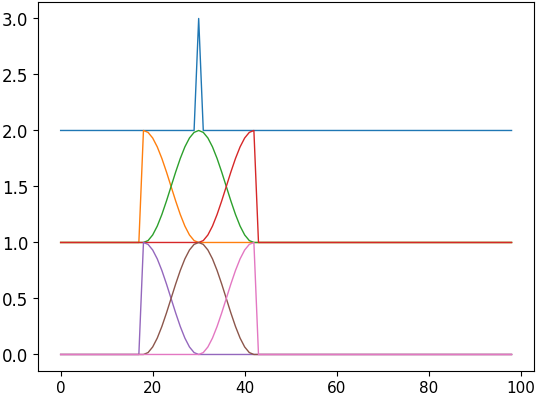

In [320]:
# check the spatial convolution
plt.plot(X[timeinds2, :].T + 2)
plt.plot(Xconv[1][timeinds2,:,:] + 1)
plt.plot(Xconv2[1][timeinds2,:,:])

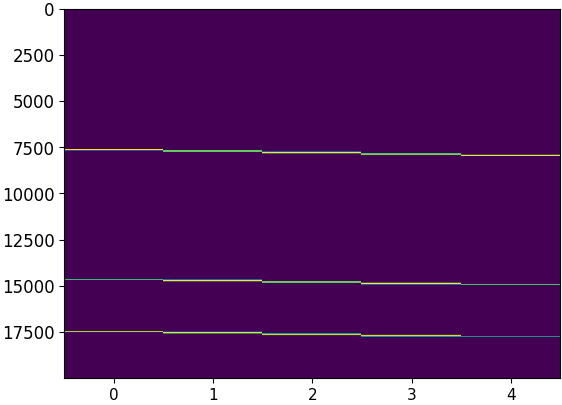

In [125]:
plt.imshow(Y[0][inds,0,:], aspect='auto', interpolation='none')